 Cell In[2], line 4
    End-to-end data analysis project using Python (Pandas) to explore sales and profitability across categories, regions, and segments in the Sample Superstore dataset.
               ^
SyntaxError: invalid syntax

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'Documents\SQL\archive (2)\SampleSuperstore.csv')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [16]:
## 1. Data Cleaning
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

df_clean = df.drop_duplicates()
print(f"\nRows before: {len(df)} | Rows after: {len(df_clean)}")

Missing values:
 Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicates: 17

Rows before: 9994 | Rows after: 9977


In [17]:
## 2. Profit & Sales by Category
category_summary = df_clean.groupby('Category')[['Sales', 'Profit']].sum().round(2).sort_values('Profit', ascending=False)
category_summary

,Sales,Profit
Category,,
Technology,836154.03,145454.95
Office Supplies,718735.24,122364.66
Furniture,741306.31,18421.81


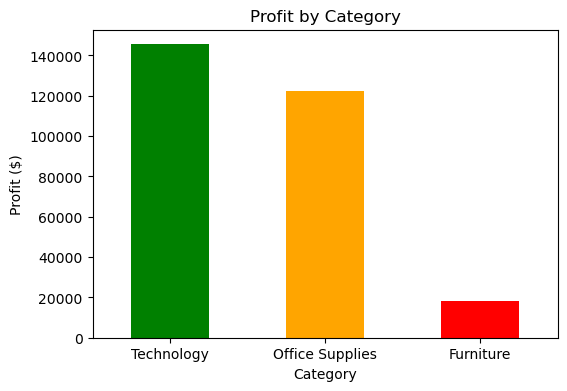

In [18]:
## 3. Sub-Category Profitability (Top Losses)
category_summary['Profit'].plot(kind='bar', color=['green', 'orange', 'red'], figsize=(6,4))
plt.title('Profit by Category')
plt.ylabel('Profit ($)')
plt.xticks(rotation=0)
plt.show()

In [19]:
## 3. Sub-Category Profitability (Top Losses)
subcat_profit = df_clean.groupby('Sub-Category')['Profit'].sum().sort_values()
subcat_profit.head(5)

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64

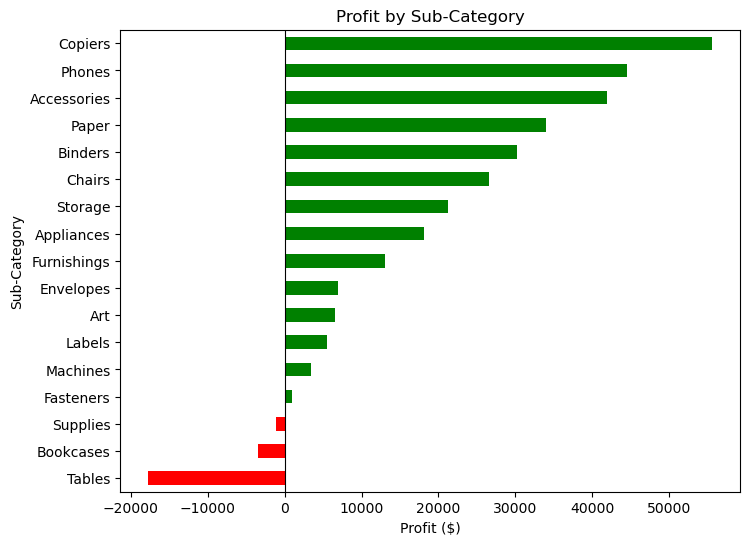

In [13]:
colors = ['red' if x < 0 else 'green' for x in subcat_profit]
subcat_profit.plot(kind='barh', color=colors, figsize=(8,6))
plt.title('Profit by Sub-Category')
plt.xlabel('Profit ($)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

In [14]:
## 4. Discount Impact on Profit
discount_profit = df_clean.groupby('Sub-Category')[['Discount', 'Profit']].mean().round(2).sort_values('Discount', ascending=False)
discount_profit.head(5)

,Discount,Profit
Sub-Category,,
Binders,0.37,19.86
Machines,0.31,29.43
Tables,0.26,-55.57
Bookcases,0.21,-15.23
Chairs,0.17,43.20


## 5. Conclusions & Recommendations

- **Technology** is the most profitable category ($145K profit), while **Furniture** generates similar sales but only $18K profit.
- **Tables** is the biggest loss-maker (-$17.7K) despite $200K+ in sales, driven by a high average discount (26%).
- **Bookcases** and **Supplies** also operate at a loss.
- Reducing discounts on Tables and Bookcases could significantly improve overall profitability without major impact on sales volume.
